In [83]:
# import Data Manipulation Libraries 
import numpy as np
import pandas as pd

# Data Visualitzastoion Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning Models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,RobustScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from imblearn.over_sampling import SMOTE


#import Logging Libraries

import logging
logging.basicConfig(level =logging.INFO,
filename = 'model.log',
filemode = 'w',
format = '%(asctime)s - %(message)s - %(levelname)s',
force = True
)

In [84]:
#Import Filter Warning Libraries

import warnings
warnings.filterwarnings(action = 'ignore')

In [85]:
#Steps to be Followed

'''
Step 1: Data Ingestion - Loading Data using pandas function
Step 2: Understand Dataset - Categorical and Numerical Column Information.
Step 3: Descriptive Stats - for Categorical and Numerical Columns.
Step 4: Build Strategies: based on type and nature of dataset and accordingly do preprocessing

'''

'\nStep 1: Data Ingestion - Loading Data using pandas function\nStep 2: Understand Dataset - Categorical and Numerical Column Information.\nStep 3: Descriptive Stats - for Categorical and Numerical Columns.\nStep 4: Build Strategies: based on type and nature of dataset and accordingly do preprocessing\n\n'

In [86]:
try:
  df = pd.read_csv(r'C:\telecom_churnmodel\data\churn.csv')
except :
  print('File not Found')
  

In [87]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [88]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

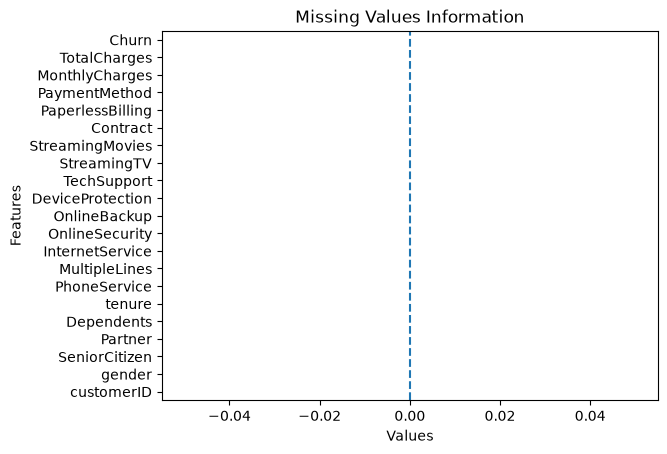

In [89]:
# Checking Missing Values Information using Graph

df.isnull().sum().plot(kind = 'barh')
plt.axvline(0,linestyle = '--')
plt.title('Missing Values Information')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

In [90]:
# Checking Duplicated values and Drop the Same

'''
No Duplicated Values Found in Dataset
'''

# Checking Descriptive Statistics

numerical_data = df.select_dtypes(exclude = 'object')
categorical_data = df.select_dtypes(include = 'object')

In [91]:
categorical_data.columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [92]:
# Checking dataset columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
# Encoding Target Column 
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,1


In [94]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

[]

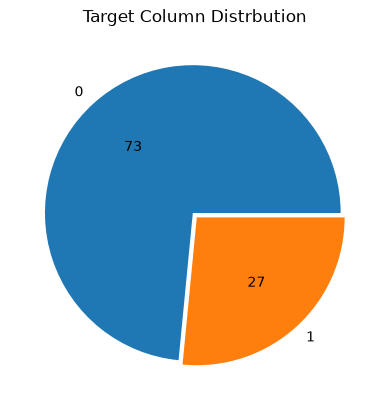

In [95]:
df['Churn'].value_counts().plot(kind = 'pie', autopct = '%0.0f', explode = [0.02,0.02])
plt.title('Target Column Distrbution')
plt.plot()

In [96]:
# Using Encoding Technique 

le = LabelEncoder()
for i in categorical_data.columns:
    df[i] = le.fit_transform(df[i])   
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,2505,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1466,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1400,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4853,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1597,0
7039,1525,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,5698,0
7040,3367,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,2994,0
7041,5934,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,2660,1


In [97]:
# Dropping Unwanted Columns

df.drop(columns ='customerID',inplace = True)

In [98]:
df.shape

(7043, 20)

In [99]:
# Data Preprocessing
'''

1. Nature of Machine Learning Problem : Classification Model
2. Target Column : Categorical Nature ( Yes : 1, No : 0)
3. Before Machine Learning  model ensure dataset must be balanced
4. Ensure Data Leakage not happens during execution of model
    - If Data Leakage is found the the model is Overfit.
5. Matrix for Classification Model are as follows:
    - Confusion Matrix (TP,TN,FP,FN)
    - Accuracy, Precision , Recall, F1 - Score
    - ROC and AUC curve

=======================================================================================================

# Concept Of Preventing Data Leakage
    - Split the Data into Inputs Features and Target Column i.e X and y
    - Split the dataset into train and test i.e. Seen Data and Unseen Data
    - Now use over sampling or under sampling technique in order to balance target column
    - Building Machine Learning Model

'''

'\n\n1. Nature of Machine Learning Problem : Classification Model\n2. Target Column : Categorical Nature ( Yes : 1, No : 0)\n3. Before Machine Learning  model ensure dataset must be balanced\n4. Ensure Data Leakage not happens during execution of model\n    - If Data Leakage is found the the model is Overfit.\n5. Matrix for Classification Model are as follows:\n    - Confusion Matrix (TP,TN,FP,FN)\n    - Accuracy, Precision , Recall, F1 - Score\n    - ROC and AUC curve\n\n=======================================================================================================\n\n# Concept Of Preventing Data Leakage\n    - Split the Data into Inputs Features and Target Column i.e X and y\n    - Split the dataset into train and test i.e. Seen Data and Unseen Data\n    - Now use over sampling or under sampling technique in order to balance target column\n    - Building Machine Learning Model\n\n'

In [100]:
# Split the dataset into input features and target columns i.e. X and y 

X = df.drop(columns = 'Churn')
y = df['Churn']

In [ ]:
# Split the dataset into train and test : Seen and Unseen Data 

X_train,X_test,y_train,y_test = train_test_split( X,y,
                                                test_size = 0.3,
                                                random_state = 1)

In [102]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()

X_train,y_train = sm.fit_resample(X_train,y_train)

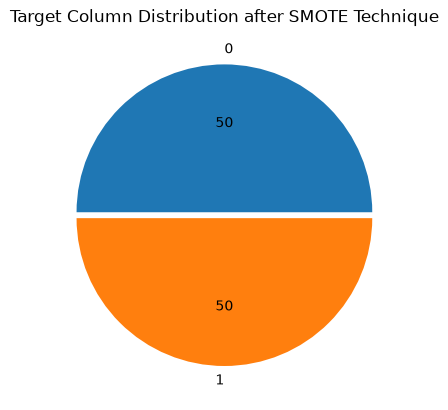

In [103]:
y_train.value_counts().plot(kind = 'pie',
                            autopct = '%0.0f',
                            explode = [0.02,0.02])
plt.title('Target Column Distribution after SMOTE Technique')
plt.show()

In [104]:
# Building Logistic Regression Model

from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression().fit(X_train,y_train)
y_pred_LR = model_LR.predict(X_test)

accuracy_score = accuracy_score(y_test,y_pred_LR)
accuracy_score

0.7685754850922859

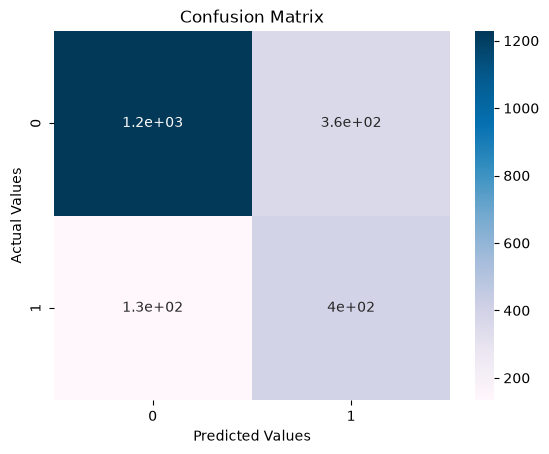

In [105]:
cf = confusion_matrix(y_test,y_pred_LR)
sns.heatmap(cf,annot = True,cmap ='PuBu')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


In [106]:
classificationreport_LR = classification_report(y_test,y_pred_LR)
print(classificationreport_LR)

              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1585
           1       0.53      0.75      0.62       528

    accuracy                           0.77      2113
   macro avg       0.71      0.76      0.73      2113
weighted avg       0.81      0.77      0.78      2113



In [107]:
from sklearn.metrics import accuracy_score
# Train the model
model_DT = DecisionTreeClassifier().fit(X_train, y_train)

# Predict on test data
y_pred_DT = model_DT.predict(X_test)

# Calculate accuracy
accuracy_score_DT = accuracy_score(y_test, y_pred_DT)

# Print accuracy
print("Decision Tree Accuracy:", accuracy_score_DT)

Decision Tree Accuracy: 0.735447231424515


In [108]:
classificationreport_DT= classification_report(y_test,y_pred_DT)
print(classificationreport_DT)

              precision    recall  f1-score   support

           0       0.85      0.78      0.82      1585
           1       0.48      0.60      0.53       528

    accuracy                           0.74      2113
   macro avg       0.66      0.69      0.67      2113
weighted avg       0.76      0.74      0.74      2113



In [109]:
model_RF = RandomForestClassifier().fit(X_train,y_train)
y_pred_RF = model_RF.predict(X_test)

accuracy_score_RF = accuracy_score(y_test,y_pred_RF)
accuracy_score_RF

0.7818267865593942

In [110]:
classificationreport_RF = classification_report(y_test,y_pred_RF)
print(classificationreport_RF)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1585
           1       0.56      0.63      0.59       528

    accuracy                           0.78      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.79      0.78      0.79      2113



In [111]:
sm = SMOTE(random_state=42).fit(X_train,y_train)
X_train, y_train = sm.fit_resample(X_train, y_train)

print('Resampled dataset shape %s' ,(y_train))

classificationreport_sm= classification_report(y_test,y_pred_RF)
print(classificationreport_sm)




Resampled dataset shape %s 0       0
1       1
2       1
3       1
4       0
       ..
7173    1
7174    1
7175    1
7176    1
7177    1
Name: Churn, Length: 7178, dtype: int64
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1585
           1       0.56      0.63      0.59       528

    accuracy                           0.78      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.79      0.78      0.79      2113



In [112]:
from sklearn.neighbors import KNeighborsClassifier

model_KNN = KNeighborsClassifier().fit(X_train,y_train)
y_pred_KNN = model_KNN.predict(X_test)

accuracy_score_KNN = accuracy_score(y_test,y_pred_KNN)
accuracy_score_KNN

classificationreport_KNN = classification_report(y_test,y_pred_KNN)
print(classificationreport_KNN)

              precision    recall  f1-score   support

           0       0.86      0.71      0.78      1585
           1       0.43      0.64      0.51       528

    accuracy                           0.69      2113
   macro avg       0.64      0.68      0.65      2113
weighted avg       0.75      0.69      0.71      2113



In [113]:
from sklearn.svm import SVC

model_svm = SVC().fit(X_train,y_train)
y_pred_svm = model_svm.predict(X_test)

accuracy_score_svm = accuracy_score(y_test,y_pred_svm)
accuracy_score_svm

classificationreport_svm = classification_report(y_test,y_pred_svm)
print(classificationreport_svm)

              precision    recall  f1-score   support

           0       0.81      0.55      0.66      1585
           1       0.31      0.62      0.42       528

    accuracy                           0.57      2113
   macro avg       0.56      0.58      0.54      2113
weighted avg       0.69      0.57      0.60      2113

